# **성능 최적화 : 과적합 방지**

* 패션 아이템 이미지 10가지 분류하기
    * 데이터 : 이미지(1, 32, 32) 6만장
    * 10가지 클래스로 분류하기 위한 모델 생성

![](https://www.researchgate.net/publication/346405197/figure/fig3/AS:962581560848384@1606508736352/Examples-of-Fashion-MNIST-dataset.ppm)


## 1.환경준비

### (1) 라이브러리 Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim import Adam
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torchsummary import summary

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [4]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # long = int64
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [5]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [6]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [7]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')
    plt.plot(epochs, val_acc_list, label='val_acc', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [8]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### (4) 데이터 셋

* 다운로드

In [9]:
train_dataset = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.36MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 66.1MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.9MB/s]


* 데이터 축소
    * 다양한 실험을 하기 위해 데이터 사이즈를 줄여서 진행합니다.

In [10]:
# 데이터와 레이블 추출
train_data = train_dataset.data.numpy() / 255
train_labels = train_dataset.targets.numpy()
test_data = test_dataset.data.numpy() / 255
test_labels = test_dataset.targets.numpy()

# 데이터 샘플링, 층화추출
x_train, _, y_train, _ = train_test_split(train_data, train_labels, test_size = 40000, random_state = 10, stratify = train_labels)
x_val, x_test, y_val, y_test = train_test_split(test_data, test_labels, test_size = 5000, random_state = 10, stratify = test_labels)

# 3 --> 4차원으로 변환
x_train = x_train.reshape(20000, 1, 28, 28)
x_val = x_val.reshape(5000, 1, 28, 28)
x_test = x_test.reshape(5000, 1, 28, 28)

# tensor로 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# train_dataset으로 변환
train_TensorDS = TensorDataset(x_train, y_train)

* 데이터셋의 x와 y

In [11]:
x_train.shape, y_train.shape

(torch.Size([20000, 1, 28, 28]), torch.Size([20000]))

* y(target)의 클래스

In [12]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

* train은 데이터로더로 생성

In [13]:
batch_size = 64
train_dataloader = DataLoader(train_TensorDS, batch_size=batch_size)

In [14]:
# 첫번째 배치만 로딩해서 살펴보기
for X, y in train_dataloader:
    print(f"Shape of X [batch, channels, height, width]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


## 2.모델링 : 과적합

### (1) 모델 선언

In [15]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 128),  # 7의 반으로 줄어들 때, 3으로 계산
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
              ReLU-8            [-1, 128, 7, 7]               0
         MaxPool2d-9            [-1, 128, 3, 3]               0
          Flatten-10                 [-1, 1152]               0
           Linear-11                  [-1, 128]         147,584
             ReLU-12                  [-1, 128]               0
           Linear-13                   [-1, 64]           8,256
             ReLU-14                   

### (2) 학습

Epoch 1, train loss : 0.8297, val loss : 0.5751, val acc : 0.7808
Epoch 2, train loss : 0.4997, val loss : 0.4629, val acc : 0.8314
Epoch 3, train loss : 0.4103, val loss : 0.3982, val acc : 0.8550
Epoch 4, train loss : 0.3532, val loss : 0.3701, val acc : 0.8644
Epoch 5, train loss : 0.3158, val loss : 0.3560, val acc : 0.8722
Epoch 6, train loss : 0.2880, val loss : 0.3489, val acc : 0.8754
Epoch 7, train loss : 0.2647, val loss : 0.3424, val acc : 0.8824
Epoch 8, train loss : 0.2412, val loss : 0.3414, val acc : 0.8846
Epoch 9, train loss : 0.2195, val loss : 0.3380, val acc : 0.8926
Epoch 10, train loss : 0.2020, val loss : 0.3465, val acc : 0.8890
Epoch 11, train loss : 0.1858, val loss : 0.3440, val acc : 0.8892
Epoch 12, train loss : 0.1659, val loss : 0.3392, val acc : 0.8942
Epoch 13, train loss : 0.1494, val loss : 0.3442, val acc : 0.8906
Epoch 14, train loss : 0.1365, val loss : 0.3810, val acc : 0.8886
Epoch 15, train loss : 0.1344, val loss : 0.3749, val acc : 0.8934
Epoc

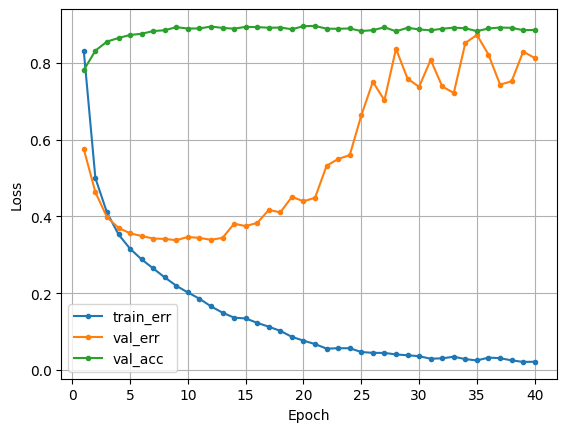

In [16]:
epochs = 40
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### (3) 모델 평가

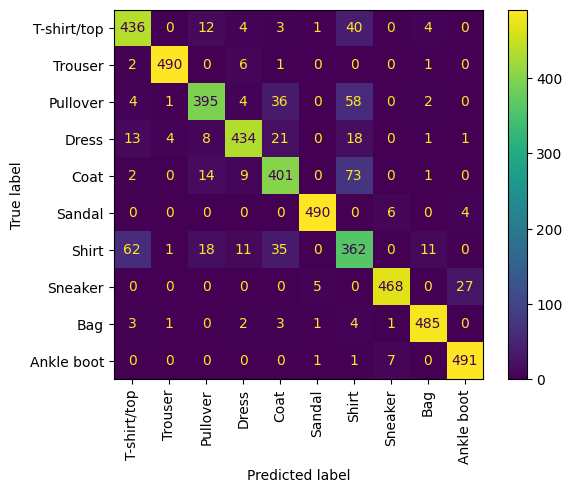

Accuracy : 0.8904
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.87      0.85       500
     Trouser       0.99      0.98      0.98       500
    Pullover       0.88      0.79      0.83       500
       Dress       0.92      0.87      0.89       500
        Coat       0.80      0.80      0.80       500
      Sandal       0.98      0.98      0.98       500
       Shirt       0.65      0.72      0.69       500
     Sneaker       0.97      0.94      0.95       500
         Bag       0.96      0.97      0.97       500
  Ankle boot       0.94      0.98      0.96       500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



In [17]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

## 3.모델링 : Early Stopping

### (1) 모델 선언

In [18]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 128),  # 7의 반으로 줄어들 때, 3으로 계산
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
              ReLU-8            [-1, 128, 7, 7]               0
         MaxPool2d-9            [-1, 128, 3, 3]               0
          Flatten-10                 [-1, 1152]               0
           Linear-11                  [-1, 128]         147,584
             ReLU-12                  [-1, 128]               0
           Linear-13                   [-1, 64]           8,256
             ReLU-14                   

### (2) 학습

In [19]:
epochs = 40
tr_loss_list, val_loss_list, val_acc_list = [], [], []

# early stopping을 위한 변수 설정 ----------------
patience = 3
best_loss = float('inf')  # 초기값을 무한대로 설정
counter = 0
# ------------------------------------------------

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

    # early stopping 확인 -------------------
    if val_loss > best_loss:
            counter += 1
            print(f'--> early stopping status, best_loss : {best_loss:4f}, counter : {counter}')

    else:
        best_loss = val_loss
        counter = 0

    # 조기 종료 조건 확인
    if counter >= patience:
        print("Early Stopping!")
        break
    # ----------------------------------------

Epoch 1, train loss : 0.8110, val loss : 0.5536, val acc : 0.7986
Epoch 2, train loss : 0.4828, val loss : 0.4444, val acc : 0.8374
Epoch 3, train loss : 0.3928, val loss : 0.3860, val acc : 0.8588
Epoch 4, train loss : 0.3436, val loss : 0.3908, val acc : 0.8566
--> early stopping status, best_loss : 0.386013, counter : 1
Epoch 5, train loss : 0.3109, val loss : 0.3693, val acc : 0.8672
Epoch 6, train loss : 0.2830, val loss : 0.3571, val acc : 0.8724
Epoch 7, train loss : 0.2584, val loss : 0.3551, val acc : 0.8778
Epoch 8, train loss : 0.2388, val loss : 0.3404, val acc : 0.8828
Epoch 9, train loss : 0.2191, val loss : 0.3307, val acc : 0.8890
Epoch 10, train loss : 0.2022, val loss : 0.3307, val acc : 0.8898
Epoch 11, train loss : 0.1843, val loss : 0.3250, val acc : 0.8928
Epoch 12, train loss : 0.1694, val loss : 0.3389, val acc : 0.8894
--> early stopping status, best_loss : 0.325002, counter : 1
Epoch 13, train loss : 0.1543, val loss : 0.3815, val acc : 0.8722
--> early stoppi

* 학습 곡선

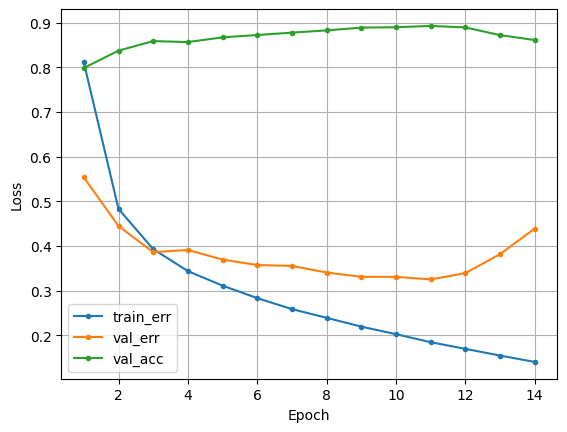

In [20]:
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### (3) 예측 및 평가

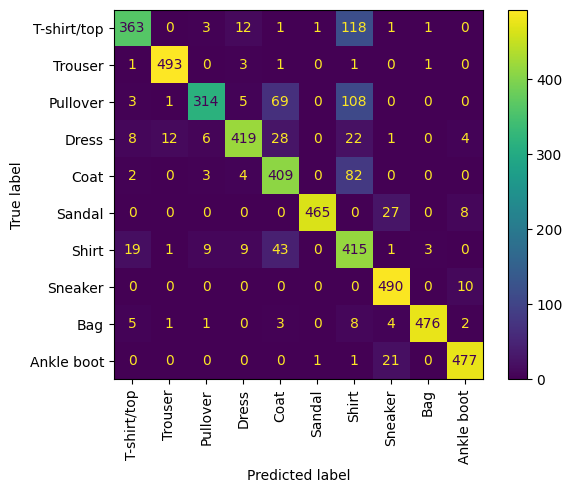

Accuracy : 0.8642
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.91      0.73      0.81       500
     Trouser       0.97      0.99      0.98       500
    Pullover       0.93      0.63      0.75       500
       Dress       0.93      0.84      0.88       500
        Coat       0.74      0.82      0.78       500
      Sandal       1.00      0.93      0.96       500
       Shirt       0.55      0.83      0.66       500
     Sneaker       0.90      0.98      0.94       500
         Bag       0.99      0.95      0.97       500
  Ankle boot       0.95      0.95      0.95       500

    accuracy                           0.86      5000
   macro avg       0.89      0.86      0.87      5000
weighted avg       0.89      0.86      0.87      5000



In [21]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### (4) 모델 저장

* early stopping에서, best loss에 해당하는 모델을 저장하기

#### 1) 모델 선언

In [22]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 128),  # 7의 반으로 줄어들 때, 3으로 계산
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
              ReLU-8            [-1, 128, 7, 7]               0
         MaxPool2d-9            [-1, 128, 3, 3]               0
          Flatten-10                 [-1, 1152]               0
           Linear-11                  [-1, 128]         147,584
             ReLU-12                  [-1, 128]               0
           Linear-13                   [-1, 64]           8,256
             ReLU-14                   

#### 2) 학습

In [23]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

# early stopping을 위한 변수 설정
patience = 3
best_loss = float('inf')  # 초기값을 무한대로 설정
counter = 0

# 모델 저장 경로
PATH = './model.pt'

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

    # early stopping 확인 -------------------
    if val_loss > best_loss:
        counter += 1
        print(f'--> early stopping status, best_loss : {best_loss:4f}')
    else:
        best_loss = val_loss
        counter = 0
        torch.save(model, PATH)  # <- best model 저장하기

    # 조기 종료 조건 확인
    if counter >= patience:
        print("Early Stopping!")
        break
    # ----------------------------------------

Epoch 1, train loss : 0.8540, val loss : 0.5829, val acc : 0.7802
Epoch 2, train loss : 0.5023, val loss : 0.4407, val acc : 0.8394
Epoch 3, train loss : 0.4090, val loss : 0.3879, val acc : 0.8592
Epoch 4, train loss : 0.3545, val loss : 0.3806, val acc : 0.8644
Epoch 5, train loss : 0.3201, val loss : 0.3482, val acc : 0.8764
Epoch 6, train loss : 0.2924, val loss : 0.3344, val acc : 0.8838
Epoch 7, train loss : 0.2685, val loss : 0.3170, val acc : 0.8894
Epoch 8, train loss : 0.2450, val loss : 0.3097, val acc : 0.8890
Epoch 9, train loss : 0.2248, val loss : 0.3077, val acc : 0.8918
Epoch 10, train loss : 0.2055, val loss : 0.3143, val acc : 0.8894
--> early stopping status, best_loss : 0.307658
Epoch 11, train loss : 0.1879, val loss : 0.3212, val acc : 0.8940
--> early stopping status, best_loss : 0.307658
Epoch 12, train loss : 0.1730, val loss : 0.3361, val acc : 0.8894
--> early stopping status, best_loss : 0.307658
Early Stopping!


#### 3) 저장된 모델 사용

* 모델 로딩

In [26]:
best_model = torch.load(PATH, weights_only=False)

* 예측

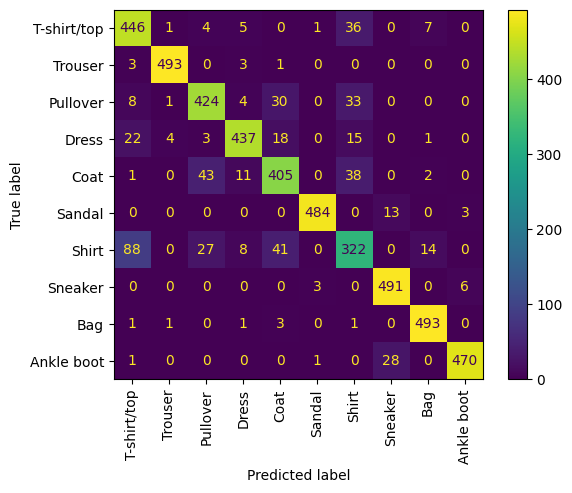

Accuracy : 0.893
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.78      0.89      0.83       500
     Trouser       0.99      0.99      0.99       500
    Pullover       0.85      0.85      0.85       500
       Dress       0.93      0.87      0.90       500
        Coat       0.81      0.81      0.81       500
      Sandal       0.99      0.97      0.98       500
       Shirt       0.72      0.64      0.68       500
     Sneaker       0.92      0.98      0.95       500
         Bag       0.95      0.99      0.97       500
  Ankle boot       0.98      0.94      0.96       500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



In [27]:
# 예측
_, pred = evaluate(x_test, y_test, best_model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

## 4.모델링 : Dropout

### (1) Dropout 추가

* 모델 선언

In [28]:
n_class = 10
dropout_rate = 0.3

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(p=dropout_rate),  # Conv2d 후에 드롭아웃 추가

    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(p=dropout_rate),  # Conv2d 후에 드롭아웃 추가

    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(p=dropout_rate),  # Conv2d 후에 드롭아웃 추가

    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 128),
    nn.ReLU(),
    nn.Dropout(p=dropout_rate),  # Dense 레이어 후에 드롭아웃 추가

    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=dropout_rate),  # Dense 레이어 후에 드롭아웃 추가

    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
         Dropout2d-4           [-1, 32, 14, 14]               0
            Conv2d-5           [-1, 64, 14, 14]          18,496
              ReLU-6           [-1, 64, 14, 14]               0
         MaxPool2d-7             [-1, 64, 7, 7]               0
         Dropout2d-8             [-1, 64, 7, 7]               0
            Conv2d-9            [-1, 128, 7, 7]          73,856
             ReLU-10            [-1, 128, 7, 7]               0
        MaxPool2d-11            [-1, 128, 3, 3]               0
        Dropout2d-12            [-1, 128, 3, 3]               0
          Flatten-13                 [-1, 1152]               0
           Linear-14                  [

### (2) 학습 및 평가

* 학습

Epoch 1, train loss : 1.1004, val loss : 0.6496, val acc : 0.7514
Epoch 2, train loss : 0.6719, val loss : 0.5453, val acc : 0.7982
Epoch 3, train loss : 0.5792, val loss : 0.4690, val acc : 0.8240
Epoch 4, train loss : 0.5240, val loss : 0.4365, val acc : 0.8366
Epoch 5, train loss : 0.4813, val loss : 0.4039, val acc : 0.8528
Epoch 6, train loss : 0.4468, val loss : 0.3820, val acc : 0.8606
Epoch 7, train loss : 0.4156, val loss : 0.3717, val acc : 0.8608
Epoch 8, train loss : 0.4052, val loss : 0.3453, val acc : 0.8734
Epoch 9, train loss : 0.3829, val loss : 0.3380, val acc : 0.8762
Epoch 10, train loss : 0.3745, val loss : 0.3287, val acc : 0.8774
Epoch 11, train loss : 0.3563, val loss : 0.3129, val acc : 0.8892
Epoch 12, train loss : 0.3469, val loss : 0.3171, val acc : 0.8850
Epoch 13, train loss : 0.3346, val loss : 0.3040, val acc : 0.8898
Epoch 14, train loss : 0.3268, val loss : 0.2975, val acc : 0.8910
Epoch 15, train loss : 0.3162, val loss : 0.2941, val acc : 0.8952
Epoc

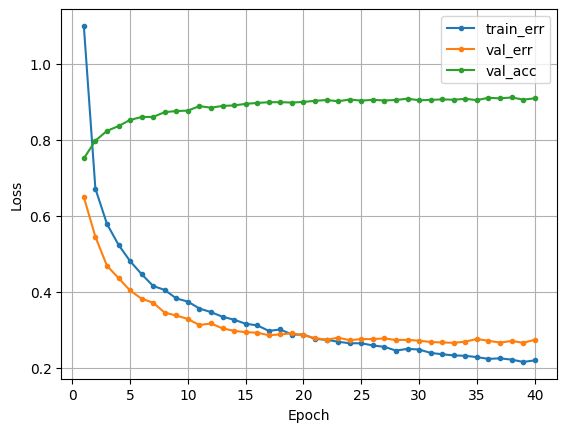

In [29]:
epochs = 40
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

* 예측

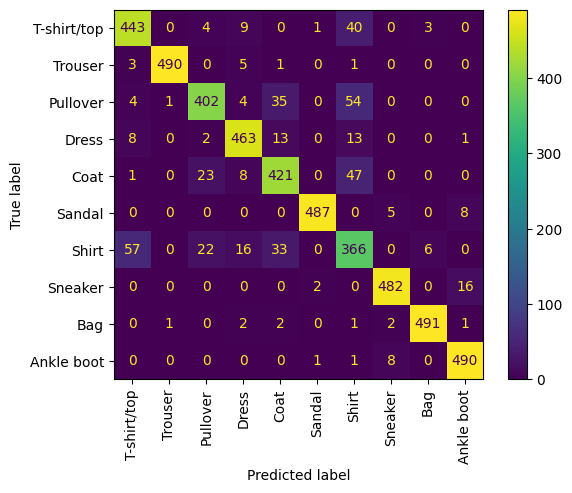

Accuracy : 0.907
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87       500
     Trouser       1.00      0.98      0.99       500
    Pullover       0.89      0.80      0.84       500
       Dress       0.91      0.93      0.92       500
        Coat       0.83      0.84      0.84       500
      Sandal       0.99      0.97      0.98       500
       Shirt       0.70      0.73      0.72       500
     Sneaker       0.97      0.96      0.97       500
         Bag       0.98      0.98      0.98       500
  Ankle boot       0.95      0.98      0.96       500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



In [30]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

## 5.실습

* 드롭아웃 비율을 조절하면서 모델 성능을 살펴 봅시다.
    * 0.1 > 0.2 > ... > 0.5

### (1) 과적합 확인

#### 1) 모델 선언
* **3.모델링 : 과적합** 모델보다 더 복잡한 모델을 선언합니다.
    * 노드수, 레이어 수를 늘립니다.

In [32]:
n_class = 10
dropout_rate = 0.2

model2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),

    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)


#### 2) 학습
* epochs = 30으로 학습시도

Epoch 1, train loss : 0.2176, val loss : 0.2740, val acc : 0.9096
Epoch 2, train loss : 0.2190, val loss : 0.2740, val acc : 0.9096
Epoch 3, train loss : 0.2264, val loss : 0.2740, val acc : 0.9096
Epoch 4, train loss : 0.2191, val loss : 0.2740, val acc : 0.9096
Epoch 5, train loss : 0.2191, val loss : 0.2740, val acc : 0.9096
Epoch 6, train loss : 0.2202, val loss : 0.2740, val acc : 0.9096
Epoch 7, train loss : 0.2212, val loss : 0.2740, val acc : 0.9096
Epoch 8, train loss : 0.2130, val loss : 0.2740, val acc : 0.9096
Epoch 9, train loss : 0.2168, val loss : 0.2740, val acc : 0.9096
Epoch 10, train loss : 0.2189, val loss : 0.2740, val acc : 0.9096
Epoch 11, train loss : 0.2136, val loss : 0.2740, val acc : 0.9096
Epoch 12, train loss : 0.2177, val loss : 0.2740, val acc : 0.9096
Epoch 13, train loss : 0.2186, val loss : 0.2740, val acc : 0.9096
Epoch 14, train loss : 0.2194, val loss : 0.2740, val acc : 0.9096
Epoch 15, train loss : 0.2174, val loss : 0.2740, val acc : 0.9096
Epoc

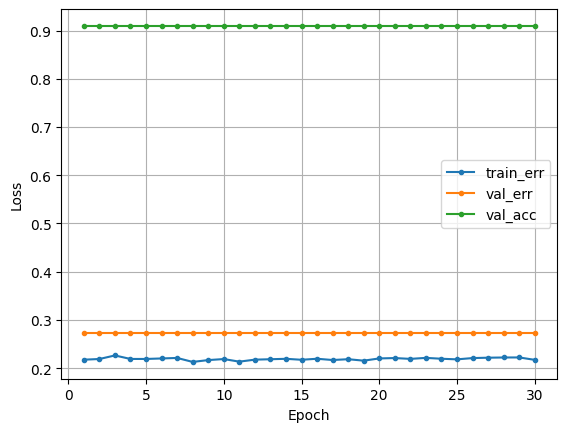

In [33]:
epochs = 30
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

#### 3) 모델평가

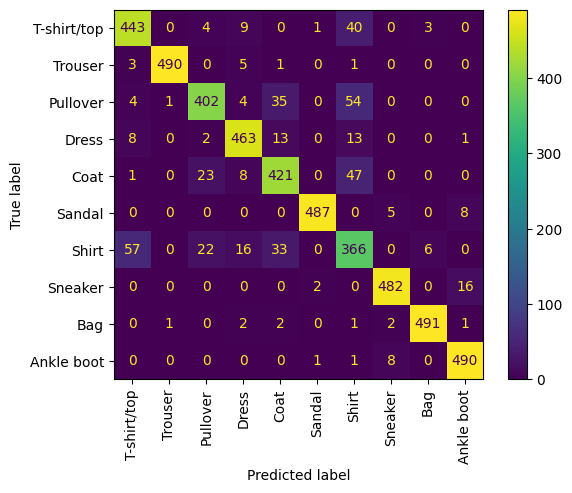

Accuracy : 0.907
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87       500
     Trouser       1.00      0.98      0.99       500
    Pullover       0.89      0.80      0.84       500
       Dress       0.91      0.93      0.92       500
        Coat       0.83      0.84      0.84       500
      Sandal       0.99      0.97      0.98       500
       Shirt       0.70      0.73      0.72       500
     Sneaker       0.97      0.96      0.97       500
         Bag       0.98      0.98      0.98       500
  Ankle boot       0.95      0.98      0.96       500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



In [34]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### (2) Early Stopping

#### 1) 모델 선언
* **(1)과적합 모델**을 그대로 사용

In [35]:
n_class = 10
dropout_rate = 0.2

model3 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),

    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001)

#### 2) 학습
* epochs = 30으로 학습시도
* Early Stopping 설정
    * patience 조정 : 1, 3, 5, 10

In [37]:
epochs = 30
tr_loss_list, val_loss_list, val_acc_list = [], [], []

# early stopping을 위한 변수 설정 ----------------
patience = 3
best_loss = float('inf')
counter = 0

# 모델 저장 경로
PATH = './model.pt'


# ------------------------------------------------

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

    # early stopping 확인 -------------------

    if val_loss > best_loss:
        counter += 1
        print(f'--> early stopping status, best_loss : {best_loss:4f}')
    else:
        best_loss = val_loss
        counter = 0
        torch.save(model, PATH)  # <- best model 저장하기

    # 조기 종료 조건 확인
    if counter >= patience:
        print("Early Stopping!")
        break

    # ----------------------------------------

Epoch 1, train loss : 0.2204, val loss : 0.2740, val acc : 0.9096
Epoch 2, train loss : 0.2160, val loss : 0.2740, val acc : 0.9096
Epoch 3, train loss : 0.2177, val loss : 0.2740, val acc : 0.9096
Epoch 4, train loss : 0.2183, val loss : 0.2740, val acc : 0.9096
Epoch 5, train loss : 0.2173, val loss : 0.2740, val acc : 0.9096
Epoch 6, train loss : 0.2180, val loss : 0.2740, val acc : 0.9096
Epoch 7, train loss : 0.2238, val loss : 0.2740, val acc : 0.9096
Epoch 8, train loss : 0.2162, val loss : 0.2740, val acc : 0.9096
Epoch 9, train loss : 0.2192, val loss : 0.2740, val acc : 0.9096
Epoch 10, train loss : 0.2185, val loss : 0.2740, val acc : 0.9096
Epoch 11, train loss : 0.2171, val loss : 0.2740, val acc : 0.9096
Epoch 12, train loss : 0.2158, val loss : 0.2740, val acc : 0.9096
Epoch 13, train loss : 0.2220, val loss : 0.2740, val acc : 0.9096
Epoch 14, train loss : 0.2165, val loss : 0.2740, val acc : 0.9096
Epoch 15, train loss : 0.2209, val loss : 0.2740, val acc : 0.9096
Epoc

#### 3) 모델평가

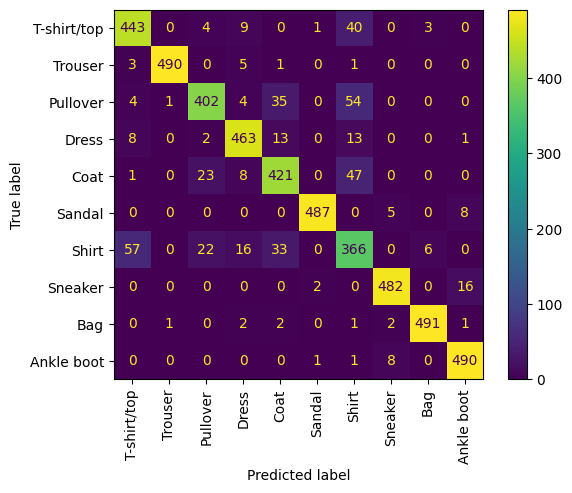

Accuracy : 0.907
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87       500
     Trouser       1.00      0.98      0.99       500
    Pullover       0.89      0.80      0.84       500
       Dress       0.91      0.93      0.92       500
        Coat       0.83      0.84      0.84       500
      Sandal       0.99      0.97      0.98       500
       Shirt       0.70      0.73      0.72       500
     Sneaker       0.97      0.96      0.97       500
         Bag       0.98      0.98      0.98       500
  Ankle boot       0.95      0.98      0.96       500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



In [38]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### (3) Dropout

#### 1) Dropout 비율 조정하며 학습곡선 확인하기
* **(1)과적합 모델**에 드롭아웃 추가
    * dropout rate : 0.1, 0.2, 0.3, 0.5 수행해보기

* 설계

In [39]:
n_class = 10
dropout_rate = 0.5

model5 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),

    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model5.parameters(), lr = 0.001)

* 학습
    * epochs = 30으로 학습시도

Epoch 1, train loss : 0.2188, val loss : 0.2740, val acc : 0.9096
Epoch 2, train loss : 0.2203, val loss : 0.2740, val acc : 0.9096
Epoch 3, train loss : 0.2197, val loss : 0.2740, val acc : 0.9096
Epoch 4, train loss : 0.2186, val loss : 0.2740, val acc : 0.9096
Epoch 5, train loss : 0.2242, val loss : 0.2740, val acc : 0.9096
Epoch 6, train loss : 0.2167, val loss : 0.2740, val acc : 0.9096
Epoch 7, train loss : 0.2184, val loss : 0.2740, val acc : 0.9096
Epoch 8, train loss : 0.2157, val loss : 0.2740, val acc : 0.9096
Epoch 9, train loss : 0.2198, val loss : 0.2740, val acc : 0.9096
Epoch 10, train loss : 0.2198, val loss : 0.2740, val acc : 0.9096
Epoch 11, train loss : 0.2223, val loss : 0.2740, val acc : 0.9096
Epoch 12, train loss : 0.2170, val loss : 0.2740, val acc : 0.9096
Epoch 13, train loss : 0.2204, val loss : 0.2740, val acc : 0.9096
Epoch 14, train loss : 0.2166, val loss : 0.2740, val acc : 0.9096
Epoch 15, train loss : 0.2180, val loss : 0.2740, val acc : 0.9096
Epoc

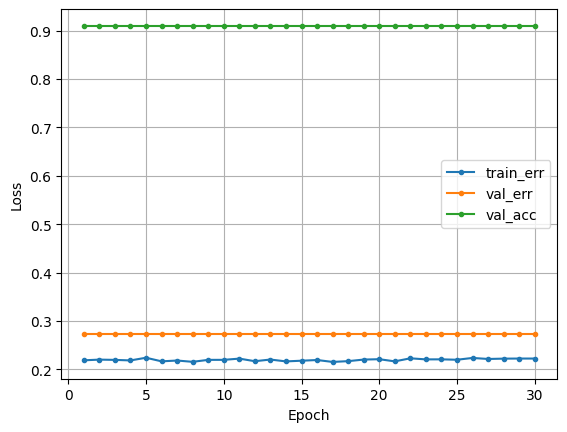

In [40]:
epochs = 30
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

* 모델평가

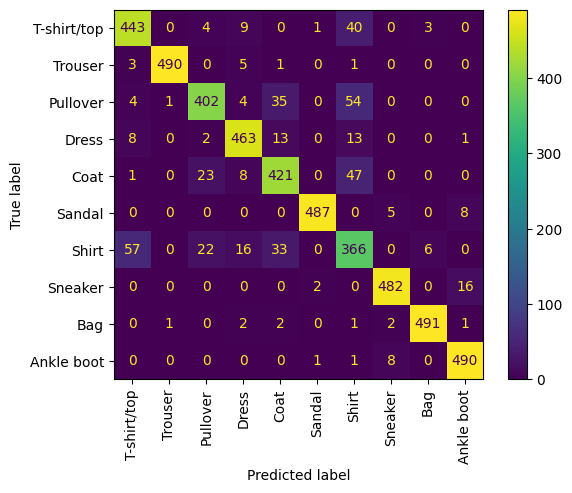

Accuracy : 0.907
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87       500
     Trouser       1.00      0.98      0.99       500
    Pullover       0.89      0.80      0.84       500
       Dress       0.91      0.93      0.92       500
        Coat       0.83      0.84      0.84       500
      Sandal       0.99      0.97      0.98       500
       Shirt       0.70      0.73      0.72       500
     Sneaker       0.97      0.96      0.97       500
         Bag       0.98      0.98      0.98       500
  Ankle boot       0.95      0.98      0.96       500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



In [41]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

* 설계

In [43]:
n_class = 10
dropout_rate= 0.2

model6 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),

    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model6.parameters(), lr = 0.001)

* 학습
    * epochs = 30으로 학습시도

Epoch 1, train loss : 0.2154, val loss : 0.2740, val acc : 0.9096
Epoch 2, train loss : 0.2181, val loss : 0.2740, val acc : 0.9096
Epoch 3, train loss : 0.2197, val loss : 0.2740, val acc : 0.9096
Epoch 4, train loss : 0.2170, val loss : 0.2740, val acc : 0.9096
Epoch 5, train loss : 0.2198, val loss : 0.2740, val acc : 0.9096
Epoch 6, train loss : 0.2170, val loss : 0.2740, val acc : 0.9096
Epoch 7, train loss : 0.2185, val loss : 0.2740, val acc : 0.9096
Epoch 8, train loss : 0.2168, val loss : 0.2740, val acc : 0.9096
Epoch 9, train loss : 0.2228, val loss : 0.2740, val acc : 0.9096
Epoch 10, train loss : 0.2195, val loss : 0.2740, val acc : 0.9096
Epoch 11, train loss : 0.2161, val loss : 0.2740, val acc : 0.9096
Epoch 12, train loss : 0.2179, val loss : 0.2740, val acc : 0.9096
Epoch 13, train loss : 0.2172, val loss : 0.2740, val acc : 0.9096
Epoch 14, train loss : 0.2167, val loss : 0.2740, val acc : 0.9096
Epoch 15, train loss : 0.2191, val loss : 0.2740, val acc : 0.9096
Epoc

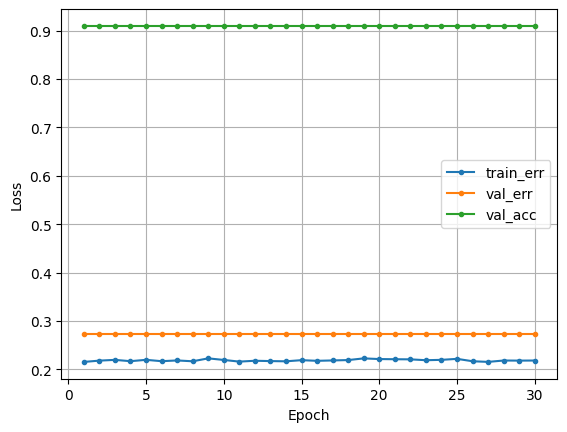

In [44]:
epochs = 30
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

* 모델평가

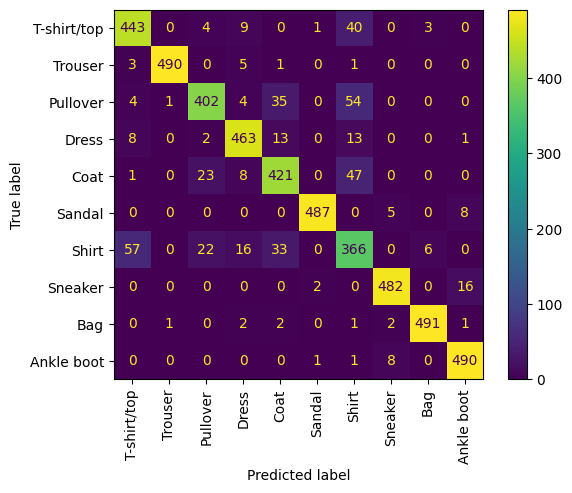

Accuracy : 0.907
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87       500
     Trouser       1.00      0.98      0.99       500
    Pullover       0.89      0.80      0.84       500
       Dress       0.91      0.93      0.92       500
        Coat       0.83      0.84      0.84       500
      Sandal       0.99      0.97      0.98       500
       Shirt       0.70      0.73      0.72       500
     Sneaker       0.97      0.96      0.97       500
         Bag       0.98      0.98      0.98       500
  Ankle boot       0.95      0.98      0.96       500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



In [45]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

#### 2) [추가]dropout + early stopping
* 다음 설정으로 둘을 한꺼번에 적용해 봅시다.
    * dropout rate : 0.3
    * early stopping - patient : 3

* 모델 설계

In [47]:
n_class = 10
dropout_rate = 0.4

model7 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(p=dropout_rate),

    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model7.parameters(), lr=0.001)

Epoch 1, train loss : 0.2144, val loss : 0.2740, val acc : 0.9096
Epoch 2, train loss : 0.2182, val loss : 0.2740, val acc : 0.9096
Epoch 3, train loss : 0.2188, val loss : 0.2740, val acc : 0.9096
Epoch 4, train loss : 0.2204, val loss : 0.2740, val acc : 0.9096
Epoch 5, train loss : 0.2189, val loss : 0.2740, val acc : 0.9096
Epoch 6, train loss : 0.2165, val loss : 0.2740, val acc : 0.9096
Epoch 7, train loss : 0.2196, val loss : 0.2740, val acc : 0.9096
Epoch 8, train loss : 0.2220, val loss : 0.2740, val acc : 0.9096
Epoch 9, train loss : 0.2169, val loss : 0.2740, val acc : 0.9096
Epoch 10, train loss : 0.2175, val loss : 0.2740, val acc : 0.9096
Epoch 11, train loss : 0.2190, val loss : 0.2740, val acc : 0.9096
Epoch 12, train loss : 0.2233, val loss : 0.2740, val acc : 0.9096
Epoch 13, train loss : 0.2209, val loss : 0.2740, val acc : 0.9096
Epoch 14, train loss : 0.2192, val loss : 0.2740, val acc : 0.9096
Epoch 15, train loss : 0.2166, val loss : 0.2740, val acc : 0.9096
Epoc

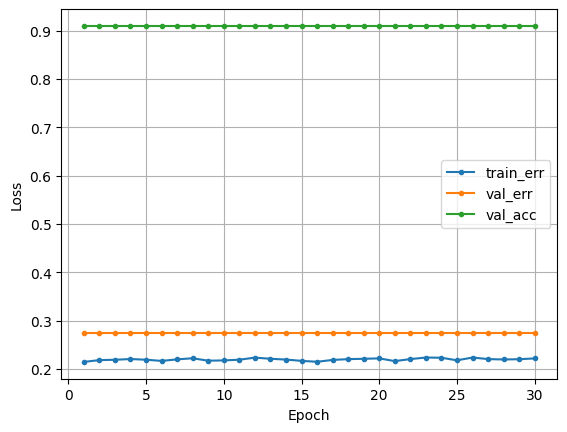

In [48]:
epochs = 30
tr_loss_list, val_loss_list, val_acc_list = [], [], []

# early stopping을 위한 변수 설정 ----------------

patience = 3
best_loss = float('inf')
counter = 0

PATH = './model.pt'

# ------------------------------------------------

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

    # early stopping 확인 -------------------
    if val_loss > best_loss:
        counter += 1
        print(f'--> early stopping status - best_loss : {best_loss:4f}')
    else:
        best_loss = val_loss
        counter = 0
        torch.save(model7, PATH)

    if counter >= patience:
        print("Early Stopping!")
        break
    # ----------------------------------------

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)